In [1]:
import sys
from pathlib import Path

# Add the project root directory to Python's import path
project_root = Path.cwd().parent
sys.path.append(str(project_root))

from PIL import Image
from src.detector import ObjectDetector

In [2]:
print("Current working directory:")
print(Path.cwd())

print("\nProject root:")
print(project_root)

print("\nPython import paths:")
print(sys.path)

Current working directory:
c:\Work\mini_adas_vision\notebooks

Project root:
c:\Work\mini_adas_vision

Python import paths:
['C:\\Users\\rushi\\AppData\\Local\\Programs\\Python\\Python313\\python313.zip', 'C:\\Users\\rushi\\AppData\\Local\\Programs\\Python\\Python313\\DLLs', 'C:\\Users\\rushi\\AppData\\Local\\Programs\\Python\\Python313\\Lib', 'C:\\Users\\rushi\\AppData\\Local\\Programs\\Python\\Python313', 'c:\\Work\\mini_adas_vision\\.venv', '', 'c:\\Work\\mini_adas_vision\\.venv\\Lib\\site-packages', 'c:\\Work\\mini_adas_vision']


In [3]:
image = Image.open("../images/road.jpg")

print("Image size:", image.size)

Image size: (500, 334)


In [4]:
detector = ObjectDetector()

Loading model: facebook/detr-resnet-50
Using device: cpu


Loading weights:   0%|          | 0/530 [00:00<?, ?it/s]

[transformers] DetrForObjectDetection LOAD REPORT from: facebook/detr-resnet-50
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
model.backbone.model.layer3.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer2.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer4.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer1.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [5]:
detections = detector.detect(image)

In [6]:
print(f"Number of detections: {len(detections)}")

for detection in detections:
    print(detection)

Number of detections: 50
{'label': 'person', 'score': 0.5495909452438354, 'box': [243.3289031982422, 176.46177673339844, 251.63018798828125, 192.98162841796875]}
{'label': 'car', 'score': 0.6830475926399231, 'box': [222.99053955078125, 171.41810607910156, 233.60618591308594, 179.91470336914062]}
{'label': 'person', 'score': 0.7110489010810852, 'box': [237.0771484375, 176.21646118164062, 246.900146484375, 196.15638732910156]}
{'label': 'person', 'score': 0.8095473051071167, 'box': [419.6012268066406, 178.13890075683594, 432.9241943359375, 216.2056884765625]}
{'label': 'person', 'score': 0.5590566992759705, 'box': [39.66762161254883, 173.23582458496094, 54.56563949584961, 221.84933471679688]}
{'label': 'person', 'score': 0.7682541608810425, 'box': [409.7339782714844, 178.51080322265625, 422.407958984375, 215.01991271972656]}
{'label': 'truck', 'score': 0.7127168774604797, 'box': [344.268310546875, 171.84300231933594, 406.4440612792969, 243.4425506591797]}
{'label': 'person', 'score': 0.6

In [7]:
from src.analyzer import ADASAnalyzer

In [8]:
analyzer = ADASAnalyzer(detections)

In [10]:
analysis = analyzer.analyze()

In [11]:
print("Object counts:")
print(analysis["object_counts"])

print("\nWarnings:")

for warning in analysis["warnings"]:
    print(f"⚠ {warning}")

Object counts:
{'vehicles': 19, 'people': 28, 'bicycles': 0, 'motorcycles': 3}

Warnings:
⚠ Pedestrian detected
⚠ Motorcycle detected


In [12]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle


def visualize_detections(image, detections):
    """
    Draw detected objects and their bounding boxes.
    """

    fig, ax = plt.subplots(figsize=(14, 8))

    ax.imshow(image)

    for detection in detections:
        label = detection["label"]
        score = detection["score"]

        xmin, ymin, xmax, ymax = detection["box"]

        # Draw bounding box
        rectangle = Rectangle(
            (xmin, ymin),
            xmax - xmin,
            ymax - ymin,
            fill=False,
            linewidth=2
        )

        ax.add_patch(rectangle)

        # Draw label
        ax.text(
            xmin,
            ymin,
            f"{label}: {score:.2f}",
            fontsize=10,
            backgroundcolor="white"
        )

    ax.axis("off")
    plt.show()

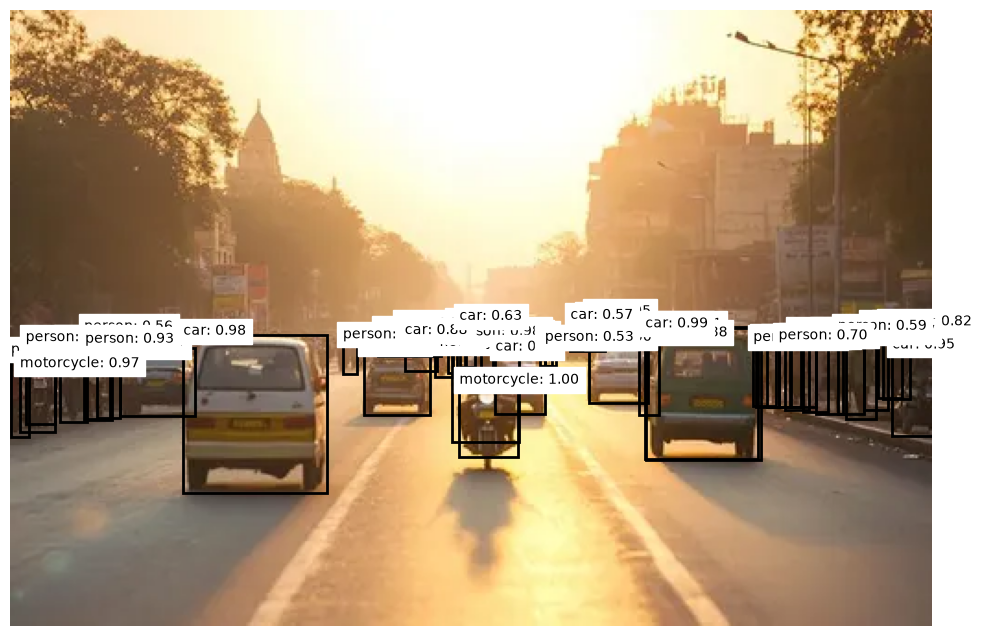

In [13]:
visualize_detections(image, detections)

In [14]:
detector = ObjectDetector(
    confidence_threshold=0.7
)

Loading model: facebook/detr-resnet-50
Using device: cpu


Loading weights:   0%|          | 0/530 [00:00<?, ?it/s]

[transformers] DetrForObjectDetection LOAD REPORT from: facebook/detr-resnet-50
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
model.backbone.model.layer3.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer2.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer4.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer1.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [15]:
detections = detector.detect(image)

In [16]:
print(f"Number of detections: {len(detections)}")

Number of detections: 35


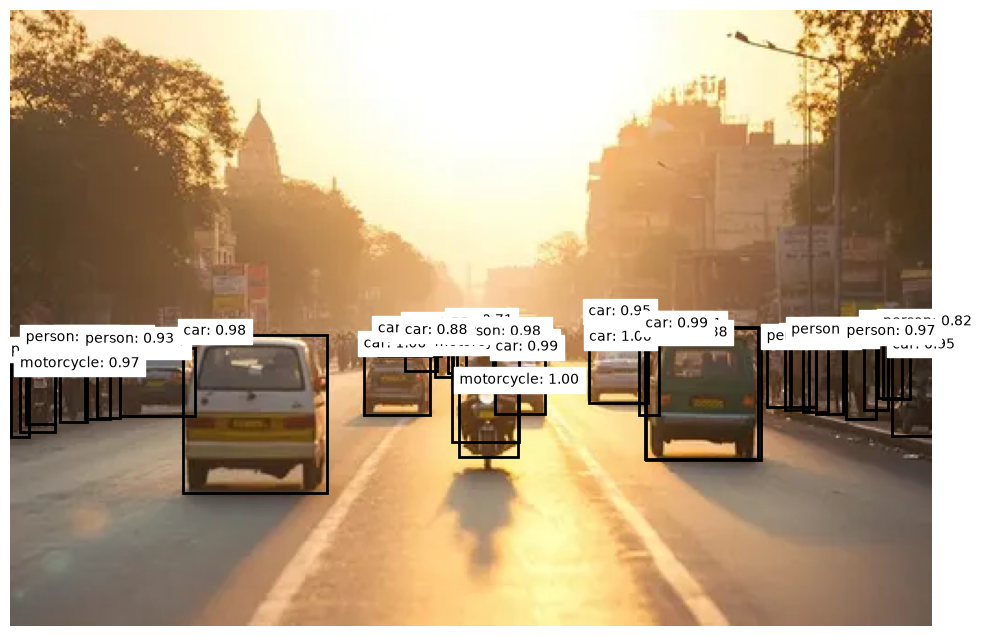

In [17]:
visualize_detections(image, detections)